# Imports, Directories and constants

In [68]:
# Imports and formatting
import csv
import numpy as np
import h5py, json
import os, re, fnmatch
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from itertools import cycle
from itertools import product
from datetime import datetime
from matplotlib.colors import LogNorm
from matplotlib.ticker import ScalarFormatter, FuncFormatter
from DiscEvolution.constants import *
from DiscEvolution.chemistry import *
from scipy.ndimage import uniform_filter1d
import matplotlib.ticker as ticker
from email import header

pd.set_option("display.max_colwidth", None)


In [69]:
# Directories
BASEDIR='/home/imontesd'
DATADIR=BASEDIR+'/output/DiscEvolution'
LITDATA=BASEDIR+'/output/DiscEvolution/litdata/'
CODEDIR=BASEDIR+'/DiscEvolution'
WORKINGDIR=BASEDIR+'/output/DiscEvolution/work/'
FIGDIR=BASEDIR+'/output/DiscEvolution/figures/'

# constants 
m_Jupiter = 317.8 # earth masses

# Chemistry
#solar_H_fraction=0.73 # by mass
X_H_solar = 0.73
X_He_solar = 0.25
mu_H = 1.0
mu_He = 4.0
mu_HHe = 2.3     # mean molecular weight of H+He mixture
Y_H = 0.92       # hydrogen fraction in primordial mixture
OH_solar = 0.00784 # mass
CH_solar = 0.00324 # mass
SiH_solar = 3.2e-5*28. # mass
CH_solar_number=CH_solar/12.
OH_solar_number=OH_solar/16.
SiH_solar_number=SiH_solar/28. 
OSi_solar_number=OH_solar_number/SiH_solar_number
Z_solar=0.02
SEC_PER_YEAR = 365.25 * 24.0 * 3600.0
ERAD_FIXED = 0.9
MU_GAS = 2.4


# key parameters
giant_thresh = 100  # Earth masses
psi_viscous = 0.01   # Viscous model psi value
psi_wind = 10       # Wind model psi value
# Define initial radius array 
initial_radii_au = [1, 2, 3, 4, 5, 7, 10, 15, 20, 25, 30]  # AUyr

# Global execution switches
GENERATE_PKL = False # Set to true to regenerate pkl files from output.  Slow.

# Main method to read .h5 output files 

In [70]:
# Method to read HDF5output files
def load_data(fname,planets=False):
    """
    Load disc evolution output file (HDF5 only).

    Returns dict in JSON-equivalent format with consistent shapes.
    """

    with h5py.File(fname, "r") as f:
        data = {}
        # Extract psi value from filename (e.g. "...psi0.01_erad0.9_Mdot...").
        # psi (= psi_DW) is the disc-wind mass-loss parameter. Units: dimensionless.
        psi = None
        m = re.search(r"psi([0-9.eE+-]+)", os.path.basename(fname))
        if m:
            psi = float(m.group(1))
        # Extract erad value from filename (e.g. "...psi0.01_erad0.9_Mdot...").
        # run_model_Hof.py::output_filename() writes the wind radiative-loss
        # efficiency into the filename as the token "erad" (the JSON config key
        # is "e_rad", with underscore) so it can be recovered here for the wind
        # mass-loss-rate calculation. Units: dimensionless fraction in [0, 1].
        # Same regex approach as psi above; stays None if the token is absent
        # (e.g. a file produced by the unmodified run_model_student.py).
        erad = None
        m = re.search(r"erad([0-9.eE+-]+)", os.path.basename(fname))
        if m:
            erad = float(m.group(1))
        # Scalars
        for key in ["t", "disk_Mdot_star", "disk_Mass", "Tc", "Sigc"]:
            if key in f:
                data[key] = f[key][()].tolist()
        data["alpha_SS"] = f.attrs.get("alpha_SS", None)
        data["psi"] = psi      # disc-wind mass-loss parameter psi_DW [dimensionless], from filename
        data["erad"] = erad    # wind radiative-loss efficiency e_rad [dimensionless, 0-1], from filename
        # Helper for ragged vs extendable vs single-dump
        def read_array(obj):
            if isinstance(obj, h5py.Dataset):       # dataset directly
                arr = obj[()]
                if np.ndim(arr) == 0:   # scalar
                    return [float(arr)]
                return np.array(arr).tolist()
            elif isinstance(obj, h5py.Group):       # ragged group
                vals = [obj[k][()] for k in sorted(obj.keys(), key=int)]
                return [float(v) for v in vals]
            else:
                raise TypeError(f"Unexpected type {type(obj)}")

        # ---------------- Per-planet arrays ----------------
        if (planets):
            data["Mcs"], data["Mes"], data["Rp"], data["disk_Mdot_p"] = [], [], [], []

            if isinstance(f.get("Mcs"), h5py.Dataset):
                # Single dataset case
                arr = np.array(f["Mcs"])
                data["Mcs"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["Mcs"].keys(), key=int):
                    data["Mcs"].append(read_array(f["Mcs"][ip]))

            if isinstance(f.get("Mes"), h5py.Dataset):
                arr = np.array(f["Mes"])
                data["Mes"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["Mes"].keys(), key=int):
                    data["Mes"].append(read_array(f["Mes"][ip]))

            if isinstance(f.get("Rp"), h5py.Dataset):
                arr = np.array(f["Rp"])
                data["Rp"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["Rp"].keys(), key=int):
                    data["Rp"].append(read_array(f["Rp"][ip]))

            if isinstance(f.get("disk_Mdot_p"), h5py.Dataset):
                arr = np.array(f["disk_Mdot_p"])
                data["disk_Mdot_p"] = [row.tolist() if arr.ndim > 1 else [float(x)] for row in np.atleast_2d(arr)]
            else:
                for ip in sorted(f["disk_Mdot_p"].keys(), key=int):
                    data["disk_Mdot_p"].append(read_array(f["disk_Mdot_p"][ip]))
        # alpha_SS handling
        if "alpha_SS" in f.attrs:             # new streaming files
            data["alpha_SS"] = float(f.attrs["alpha_SS"])
        elif "alpha_SS" in f:                  # old single-dump files
            data["alpha_SS"] = f["alpha_SS"][()]
        else:
            data["alpha_SS"] = None
        # File attributes
        data["complete"] = f.attrs.get("complete", False)

        # ---------------- Chemistry ----------------
        if (planets):
            data["X_cores"], data["X_envs"] = [], []
            if "X_cores" in f:
                if isinstance(f["X_cores"], h5py.Dataset):
                    # Single dataset case — probably shaped (nplanets, nspecies, nsteps?)
                    arr_core = np.array(f["X_cores"])
                    arr_env  = np.array(f["X_envs"])
                    nplanets = arr_core.shape[0]
                    for ip in range(nplanets):
                        core_species = [arr_core[ip, js, :].tolist() for js in range(arr_core.shape[1])]
                        env_species  = [arr_env[ip, js, :].tolist()  for js in range(arr_env.shape[1])]
                        data["X_cores"].append(core_species)
                        data["X_envs"].append(env_species)
                else:
                    # Group → streaming or ragged format
                    for ip in sorted(f["X_cores"].keys(), key=int):
                        core_species = []
                        env_species  = []
                        for js in sorted(f["X_cores"][ip].keys(), key=int):
                            core_species.append(read_array(f["X_cores"][ip][js]))
                        for js in sorted(f["X_envs"][ip].keys(), key=int):
                            env_species.append(read_array(f["X_envs"][ip][js]))
                        data["X_cores"].append(core_species)
                        data["X_envs"].append(env_species)


        # ---------------- Disk profiles ----------------
        # (CHANGED 2026-09-21, memory fix) Read straight into numpy arrays
        # instead of going through .tolist() here and np.array(...) again
        # down in "Normalize shapes" below. Why this matters: for a
        # run_model_Hof_dense.py output, "Sigma_G_dense" (and friends) can
        # be GBs of raw float64 data -- converting that to a nested Python
        # list of floats (the old f[key][:].tolist() pattern) makes every
        # single float its own Python object, which typically runs ~4-8x
        # BIGGER in RAM than the equivalent numpy array, and that list
        # briefly coexists with the array it came from AND the array it
        # gets converted back into a few lines below. On a memory-limited
        # machine that transient blow-up is enough to swap heavily or OOM.
        # h5py's f[key][:] already returns a numpy array, so just keep it
        # as one; "Normalize shapes" below now uses np.asarray(...) instead
        # of np.array(...), which does NOT copy when the input is already
        # an ndarray of the right dtype -- so this removes two redundant
        # full-size copies for every disk-profile dataset, largest savings
        # on Sigma_G_dense / Sigma_dust_dense / Sigma_pebbles_dense.
        if "R" in f:
            data["R"] = f["R"][:]
        else:
            nR = f["Sigma_G"].shape[1]
            data["R"] = np.arange(nR, dtype=float)  # placeholder if R not saved

        for key in ["Sigma_G", "Sigma_dust", "Sigma_pebbles", "T", "Sigma_pebble_size", "Vdrift"]:
            if key in f:
                data[key] = f[key][:]
        if "Sigma_planetesimals" in f:
            data["Sigma_planetesimals"] = f["Sigma_planetesimals"][:]
        # Dense-cadence Sigma_G, only present in run_model_Hof_dense.py output
        # (filename contains "_dense_"). Sigma_G_dense has one row per write
        # inside the [DENSE_T_MIN_MYR, DENSE_T_MAX_MYR] window that run used
        # (see run_model_Hof_dense.py), NOT one row per time_snap entry -- so
        # it does NOT align with Sigma_G/time_snap, and generally has far more
        # rows. Sigma_G_dense_t [years] is its own matching per-row timestamp;
        # use that, not time_snap, to plot/index into Sigma_G_dense. This is
        # typically the single largest dataset in a dense-export file -- see
        # the memory-fix note above.
        if "Sigma_G_dense" in f:
            data["Sigma_G_dense"] = f["Sigma_G_dense"][:]
        if "Sigma_G_dense_t" in f:
            data["Sigma_G_dense_t"] = f["Sigma_G_dense_t"][:]
        if "time_snap" in f:
            data["time_snap"] = f["time_snap"][:]
        # Extract ice line locations (water ice line)
        if "disk_ice_lines" in f:
            data["disk_ice_lines"] = f["disk_ice_lines"][:]
        chemdata=True
        try:
            for key in ["disk_atom_gas_abund", "disk_mol_gas_abund",
                        "disk_atom_ice_abund", "disk_mol_ice_abund",
                        "disk_planetesimal_atom_abund", "disk_planetesimal_mol_abund"]:
                if key in f:
                    data[key] = np.asarray(f[key][:], dtype=float)
        except:
            chemdata=False


    # ---------------- Normalize shapes ----------------
    # (CHANGED 2026-09-21) np.array(...) -> np.asarray(...) throughout this
    # section. The block above now hands these keys in as numpy float64
    # arrays already, so np.asarray is a no-op (no copy); np.array would
    # silently make a second full-size copy of every one of them -- see the
    # memory-fix note in "Disk profiles" above.
    data["R"] = np.asarray(data["R"], dtype=float).squeeze()  # always (nR,)

    for key in ["Sigma_G", "Sigma_dust", "Sigma_pebbles", "Sigma_planetesimals", "T", "Sigma_pebble_size"]:
        if key in data:
            arr = np.asarray(data[key], dtype=float)
            arr = np.atleast_2d(arr)          # (nsnapshots, nR)
            if arr.ndim == 3 and arr.shape[1] == 1:
                arr = arr[:, 0, :]           # squeeze accidental middle dim
            data[key] = arr

    # Ensure R is always 1D
    data["R"] = np.asarray(data["R"], dtype=float)

    if data["R"].ndim == 2:
        # Old HDF5 case: R repeated for each snapshot
        # Keep just one copy (they should all be identical)
        data["R"] = data["R"][0, :]

    data["R"] = data["R"].squeeze()


    # Normalize disk profile arrays to (nsnap, nR)
    for key in ["Sigma_G", "Sigma_dust", "Sigma_pebbles", "Sigma_planetesimals", "T", "Sigma_pebble_size"]:
        if key in data:
            arr = np.asarray(data[key], dtype=float)
            arr = np.atleast_2d(arr)  # (nsnap, nR)
            if arr.ndim == 3 and arr.shape[1] == 1:
                arr = arr[:, 0, :]
            data[key] = arr
    if "time_snap" in data:
        data["time_snap"] = np.asarray(data["time_snap"], dtype=float)
    # Sigma_G_dense / Sigma_G_dense_t: (n_dense, nR) / (n_dense,), NOT tied to
    # time_snap's length -- see comment where these are read, above.
    if "Sigma_G_dense" in data:
        data["Sigma_G_dense"] = np.atleast_2d(np.asarray(data["Sigma_G_dense"], dtype=float))   # [g/cm^2]
    if "Sigma_G_dense_t" in data:
        data["Sigma_G_dense_t"] = np.asarray(data["Sigma_G_dense_t"], dtype=float)              # [years]
    # Normalize disk_ice_lines to (nsnap, nR)
    if "disk_ice_lines" in data:
        arr = np.asarray(data["disk_ice_lines"], dtype=float)
        arr = np.atleast_2d(arr)  # (nsnap, nR)
        if arr.ndim == 3 and arr.shape[1] == 1:
            arr = arr[:, 0, :]
        data["disk_ice_lines"] = arr
    if (chemdata):
        for key in ["disk_atom_gas_abund", "disk_mol_gas_abund",
                    "disk_atom_ice_abund", "disk_mol_ice_abund",
                    "disk_planetesimal_atom_abund", "disk_planetesimal_mol_abund"]:
            if key in data:
                arr = np.asarray(data[key], dtype=float)
                # Expected shape: (nsnap, Nspecies, nR)
                if arr.ndim == 2:  # in case nsnap=1
                    arr = arr[np.newaxis, ...]
                data[key] = arr

    return data


## Other helper functions

In [71]:
# === OTHER HELPER FUNCTIONS ===
# Compute essential quantities used throughout analysis

def extract_disk_mass_from_filename(filename):
    """
    Extract initial disk mass from filename pattern (e.g., "_M1.5e-01" -> 0.15 solar masses).
    """
    if pd.isna(filename):
        return np.nan
    
    # Pattern like "_M5.0e-02" for 0.05 solar masses
    m_match = re.search(r'_M([0-9.eE+-]+)', filename)
    if m_match:
        return float(m_match.group(1))  # Solar masses
    else:
        return np.nan

def extract_e_rad_from_filename(filename):
    return None

def integrate_surface_density_mass(sim_data, sigma_key):
    """
    Integrate total mass from surface density profile:
        M = 2*pi * integral[ Sigma(R) * R dR ]
    Sigma in g/cm^2, R in AU.
    Returns mass in grams as a function of time.
    """
    if sigma_key not in sim_data:
        raise KeyError(f"{sigma_key} not found in sim_data")

    # Radius key fallback
    if "R" in sim_data:
        R_au = np.asarray(sim_data["R"], dtype=float)
    elif "Rc" in sim_data:
        R_au = np.asarray(sim_data["Rc"], dtype=float)
    else:
        raise KeyError("No radial grid found (expected sim_data['R'] or sim_data['Rc']).")

    Sigma = np.asarray(sim_data[sigma_key], dtype=float)
    R_cm = R_au * AU

    if Sigma.ndim == 1:
        # Single snapshot
        M_g = 2.0 * np.pi * np.trapezoid(Sigma * R_cm, R_cm)
        return np.array([M_g], dtype=float)

    if Sigma.ndim != 2:
        raise ValueError(f"Unexpected shape for {sigma_key}: {Sigma.shape}")

    nr = R_cm.size
    if Sigma.shape[-1] == nr:
        # Shape (nt, nr)
        M_g = 2.0 * np.pi * np.trapezoid(Sigma * R_cm[None, :], R_cm, axis=1)
    elif Sigma.shape[0] == nr:
        # Shape (nr, nt)
        M_g = 2.0 * np.pi * np.trapezoid(Sigma * R_cm[:, None], R_cm, axis=0)
    else:
        raise ValueError(f"Cannot align {sigma_key} shape {Sigma.shape} with R shape {R_cm.shape}")

    return np.asarray(M_g, dtype=float)

def _format_psi(psi):
    # Match your existing naming convention: 0.01, 10.0, etc.
    return f"{psi:.2f}" if psi < 1 else f"{psi:.1f}"

def _format_sci(x):
    # Match 1.0e-09, 5.0e-02, 5.0e+01 style
    return f"{float(x):.1e}"

def _make_filename(psi, mdot, m, rd):
    psi_str = _format_psi(float(psi))
    return (
        f"winds_mig_psi{psi_str}_"
        f"Mdot{_format_sci(mdot)}_"
        f"M{_format_sci(m)}_"
        f"Rd{_format_sci(rd)}.h5"
    )

def build_file_lists(
    mdot_values,
    m_values,
    rd_values,
    psi_viscous=psi_viscous,
    psi_wind=psi_wind,
    datadir=None,
    keep_only_existing=False
):
    combos = list(product(mdot_values, m_values, rd_values))

    visc = tuple(_make_filename(psi_viscous, mdot, m, rd) for mdot, m, rd in combos)
    wind = tuple(_make_filename(psi_wind,    mdot, m, rd) for mdot, m, rd in combos)

    if keep_only_existing:
        if datadir is None:
            raise ValueError("datadir must be provided when keep_only_existing=True")

        visc = tuple(f for f in visc if os.path.exists(os.path.join(datadir, f)))
        wind = tuple(f for f in wind if os.path.exists(os.path.join(datadir, f)))

    return visc, wind

def _as_snapshot_matrix(arr, nr, name):
    a = np.asarray(arr, dtype=float)
    if a.ndim == 1:
        if a.size != nr:
            raise ValueError(f"{name} has length {a.size}, expected {nr}")
        a = a[None, :]

    elif a.ndim == 2:
        if a.shape[-1] == nr:
            pass
        elif a.shape[0] == nr:
            a = a.T
        else:
            raise ValueError(f"Cannot align {name} shape {a.shape} with nr={nr}")

    else:
        raise ValueError(f"Unexpected {name} ndim={a.ndim}")

    return a

def _interpolate_mdot_star_to_snapshots(sim_data, t_snap):
    t_mdot = np.asarray(sim_data.get("t", []), dtype=float)
    mdot = np.asarray(sim_data.get("disk_Mdot_star", []), dtype=float)
    if t_mdot.size == 0 or mdot.size == 0:
        raise KeyError("sim_data must include 't' and 'disk_Mdot_star'")

    n = min(t_mdot.size, mdot.size)
    t_mdot = t_mdot[:n]
    mdot = mdot[:n]

    # If t is in years while snapshots are in Myr, convert t for interpolation.
    if np.nanmax(t_mdot) > 1.0e3 and np.nanmax(t_snap) < 1.0e2:
        t_mdot_use = t_mdot / 1.0e6
    else:
        t_mdot_use = t_mdot

    return np.interp(t_snap, t_mdot_use, mdot, left=np.nan, right=np.nan)

def integrate_wind_mass_loss_rate(sim_data, erad=ERAD_FIXED, mu=MU_GAS):
    """
    Integrate wind mass-loss rate over radius at each snapshot and return:
    x = stellar accretion rate at snapshot times [Msun/yr]
    y = integrated wind loss rate [Msun/yr]
    """
    if "R" in sim_data:
        R_au = np.asarray(sim_data["R"], dtype=float).squeeze()
    elif "Rc" in sim_data:
        R_au = np.asarray(sim_data["Rc"], dtype=float).squeeze()
    else:
        raise KeyError("No radial grid found (expected sim_data['R'] or sim_data['Rc'])")
    if "Sigma_G" not in sim_data or "T" not in sim_data:
        raise KeyError("sim_data must include 'Sigma_G' and 'T'")

    psi = float(sim_data.get("psi", np.nan))
    alpha_ss = float(sim_data.get("alpha_SS", np.nan))
    if not np.isfinite(psi) or not np.isfinite(alpha_ss) or psi <= 0.0:
        raise ValueError(f"Invalid psi/alpha_SS: psi={psi}, alpha_SS={alpha_ss}")

    # alpha_DW / alpha_SS = psi
    alpha_dw = psi * alpha_ss

    nr = R_au.size
    Sigma = _as_snapshot_matrix(sim_data["Sigma_G"], nr, "Sigma_G")
    Temp = _as_snapshot_matrix(sim_data["T"], nr, "T")

    t_snap = np.asarray(sim_data.get("time_snap", []), dtype=float)
    if t_snap.size == 0:
        raise KeyError("sim_data must include 'time_snap' to align with disk_Mdot_star")

    ns = min(t_snap.size, Sigma.shape[0], Temp.shape[0])
    t_snap = t_snap[:ns]
    Sigma = Sigma[:ns, :]
    Temp = Temp[:ns, :]

    R_cm = R_au * AU
    Omega_K = Omega0 * np.power(R_au, -1.5)  # Solar-mass star
    cs2 = (GasConst / mu) * Temp

    # dotSigma_w = (3/2)*(cs^2/(Omega*R^2))*(1-erad)*alpha_DW*Sigma*(3/psi + 1)
    prefac = 1.5 * (1.0 - erad) * alpha_dw * (3.0 / psi + 1.0)
    sigma_dot_w = prefac * (cs2 / (Omega_K[None, :] * R_cm[None, :]**2)) * Sigma

    # dotM_w = 2*pi*integral(dotSigma_w * R dR)
    mdot_w_g_per_s = 2.0 * np.pi * np.trapezoid(sigma_dot_w * R_cm[None, :], R_cm, axis=1)
    mdot_w_msun_per_yr = mdot_w_g_per_s * SEC_PER_YEAR / Msun

    mdot_star_snap = _interpolate_mdot_star_to_snapshots(sim_data, t_snap)

    ok = np.isfinite(mdot_star_snap) & np.isfinite(mdot_w_msun_per_yr)
    ok &= (mdot_star_snap > 0.0) & (mdot_w_msun_per_yr > 0.0)

    return mdot_star_snap[ok], mdot_w_msun_per_yr[ok], t_snap[:ns][ok]

# Custom formatter to show integers without decimals and no scientific notation
def custom_formatter(x, pos):
    try:
        # Better integer detection - check if the value is very close to an integer
        if abs(x - round(x)) < 1e-10:
            return f'{int(round(x))}'
        elif x >= 1:
            return f'{x:.1f}'
        elif x >= 0.1:
            return f'{x:.1f}'
        else:
            return f'{x:.2f}'
    except (TypeError, ValueError, OverflowError):
        # Fallback for any problematic values
        return f'{x}'

def _parse_float(s):
    s = s.strip()
    if s == "":
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

def _first_scalar(v):
    if isinstance(v, (list, tuple, np.ndarray, pd.Series)):
        return v[0]
    return v


def _extract_column_first(df_obj, candidates):
    for col in candidates:
        if col in df_obj.columns:
            return df_obj[col].apply(_first_scalar)
    raise KeyError(f"None of these columns found: {candidates}")
print("✅ HELPER FUNCTIONS defined successfully!")

✅ HELPER FUNCTIONS defined successfully!


# ----- INSERT FILENAME HERE -----
# Extract and Calculate Observables from data

In [72]:
# Extract Data from output file
filename = 'hof_discwind_sweep2.02_boundary_Mdot_inn_psi100_erad0.9_Mdot1.0e-07_M1.0e-02_Rd5.0e+01.h5'

data = load_data(os.path.join(DATADIR, filename))


## t
## t_Myr
## t_snap
## Mdisc_t
## Mdot_t

In [73]:
#Extract different quantities from the data

# Time grid
t = data["t"]
print('t extracted successfully')

t_Myr = np.asarray(t, dtype=float) / 1e6

# Snapshot grid
t_snap = data["time_snap"]
print('t_snap extracted successfully')

# Disc Mass
Mdisc_t = data["disk_Mass"]                      # Note this is total mass, gas+dust. 
                                            # Dust mass is calculated in cell below
print('Disc Mass extracted successfully')

# Mdot (accretion onto star)
Mdot_t = data["disk_Mdot_star"]
print('Mdot extracted successfully')


t extracted successfully
t_snap extracted successfully
Disc Mass extracted successfully
Mdot extracted successfully


## Mgas_tsnap

In [74]:
# Calculate gas mass 

from DiscEvolution.constants import AU, Msun
R = np.asarray(data["R"])          # AU
Mgas_tsnap = np.array([
    np.trapezoid(sigma_g_row * 2*np.pi*R, R) * AU**2 / Msun   # Msun
    for sigma_g_row in data["Sigma_G"]
])

print("Mgas_tsnap calculated successfully")
# Mgas_t is given in sun masses
# Does not exactly replicate integration approach from AccretionDisc.Mtot() in disc.py
# Variable can be used to study trends but do not use for "exact consistency" (HOF_PROJECT_GUIDE.md)

Mgas_tsnap calculated successfully


## erad
## t_snap_mask
## Mdot_tsnap
## Mdot_tsnap_mask
## Mdot_wind_tsnap_mask

In [75]:
# Extract Mdot_wind using given post-processing tool

erad = data["erad"]                                              # wind radiative-loss efficiency [dimensionless, 0-1]
print("erad extracted successfully")

Mdot_tsnap = _interpolate_mdot_star_to_snapshots(data, t_snap)   # stellar accretion rate [Msun/yr] at each t_snap [Myr]

print("Mdot_tsnap calculated successfully")

# Use this run's own erad (recovered from the filename by load_data), NOT the
# ERAD_FIXED default baked into integrate_wind_mass_loss_rate().

# integrate_wind_mass_loss_rate() drops any snapshot where EITHER rate is NaN
# (accretion interpolated outside the recorded t-range) or <= 0 (decretion /
# empty outer disc). The SAME mask is applied to both rate outputs, so they stay
# paired; the arrays are possibly SHORTER than t_snap. It also returns t_snap_mask,
# the matching snapshot times [Myr] for the kept points, so the masked rates can
# still be plotted against time. All three returned arrays have equal length.
#   Mdot_tsnap_mask       stellar accretion rate      [Msun/yr]
#   Mdot_wind_tsnap_mask   integrated disc-wind loss   [Msun/yr]
#   t_snap_mask            snapshot times (kept)       [Myr]

if data["psi"] != 0:    
    Mdot_tsnap_mask , Mdot_wind_tsnap_mask, t_snap_mask = integrate_wind_mass_loss_rate(data, erad)
    print("Mdot_tsnap_mask, Mdot_wind_tsnap_mask calculated successfully")
else:
    Mdot_tsnap_mask , Mdot_wind_tsnap_mask, t_snap_mask = None, None, None
    print("Simulation follows purely viscous model, no wind mass loss rate to be calculated")


# Might require some tinkering upstream 
# in '_integrate()' or 'write_disc_snapshot()' in run_model_student.py


erad extracted successfully
Mdot_tsnap calculated successfully
Mdot_tsnap_mask, Mdot_wind_tsnap_mask calculated successfully


In [76]:
# --- Diagnostic: which snapshots does integrate_wind_mass_loss_rate()'s mask drop? ---
#
# The function keeps a snapshot only if BOTH rates are finite and > 0, but it does
# not report which snapshots it removed. Here we recompute BOTH rates for EVERY
# snapshot (no mask), mirroring the function's math exactly, and tabulate the mask
# conditions per snapshot so the dropped points and their reason are visible.
#
# Units (mirrors integrate_wind_mass_loss_rate):
#   _R        cell-centre radii              [AU]              data["R"]
#   _Sig      gas surface density            [g/cm^2]          data["Sigma_G"], one row per t_snap
#   _T        midplane temperature           [K]               data["T"],       one row per t_snap
#   _psi      disc-wind mass-loss parameter  [dimensionless]
#   _assp     viscous alpha (alpha_SS)       [dimensionless]
#   _erad     wind radiative-loss efficiency [dimensionless, 0-1]
#   _Rcm      radii                          [cm]
#   _OmK      Keplerian angular frequency    [rad/s]           Omega0 = 2*pi / (1 yr in s)
#   _cs2      sound speed squared            [cm^2/s^2]        (R_gas / mu) * T
#   _sdw      local wind mass-loss rate      [g/cm^2/s]
#   mdot_wind_all  2*pi * integral(_sdw * R dR) = [g/s]  ->  * SEC_PER_YEAR / Msun  ->  [Msun/yr]
#   mdot_star_all  stellar accretion rate at each snapshot                            [Msun/yr]
#
# Mask keeps a snapshot iff:  Mdot_star finite & > 0  AND  Mdot_wind finite & > 0.

_R   = np.asarray(data["R"], dtype=float)          # [AU]
_Sig = np.asarray(data["Sigma_G"], dtype=float)    # [g/cm^2], shape (nsnap, nR)
_T   = np.asarray(data["T"], dtype=float)          # [K],      shape (nsnap, nR)
_ns  = min(t_snap.size, _Sig.shape[0], _T.shape[0])   # same pre-mask row cut the function makes

_psi, _assp, _erad = float(data["psi"]), float(data["alpha_SS"]), float(data["erad"])   # all dimensionless
_Rcm  = _R * AU                                                             # [cm]
_OmK  = Omega0 * _R**-1.5                                                   # [rad/s]  (Solar-mass star)
_cs2  = (GasConst / MU_GAS) * _T[:_ns]                                      # [cm^2/s^2]
if _psi != 0:
    _pref = 1.5 * (1.0 - _erad) * (_psi * _assp) * (3.0 / _psi + 1.0)          # [dimensionless]
    _sdw  = _pref * (_cs2 / (_OmK[None, :] * _Rcm[None, :]**2)) * _Sig[:_ns]   # [g/cm^2/s]
    mdot_wind_all = 2*np.pi * np.trapezoid(_sdw * _Rcm[None, :], _Rcm, axis=1) * SEC_PER_YEAR / Msun  # [Msun/yr]
else:
    _sdw = 0
    mdot_wind_all = 0

mdot_star_all = _interpolate_mdot_star_to_snapshots(data, t_snap[:_ns])                           # [Msun/yr]

# Make dataframe with booleans for each snapshot evaluating if datapoint is kept by mask or not
diag = pd.DataFrame({
    "t_snap_Myr":    t_snap[:_ns],       # [Myr]
    "Mdot_star":     mdot_star_all,      # [Msun/yr]
    "Mdot_wind":     mdot_wind_all,      # [Msun/yr]
    "star_finite":   np.isfinite(mdot_star_all),
    "star_positive": mdot_star_all > 0,
    "wind_finite":   np.isfinite(mdot_wind_all),
    "wind_positive": mdot_wind_all > 0,
})
diag["kept"] = diag[["star_finite", "star_positive", "wind_finite", "wind_positive"]].all(axis=1)

# Determine why a datapoint might have been flagged and removed
def _why(r):
    if r["kept"]:
        return ""
    reasons = []
    if not r["star_finite"]:       reasons.append("Mdot_star NaN/inf (accretion interp outside recorded t-range)")
    elif not r["star_positive"]:   reasons.append("Mdot_star <= 0")
    if not r["wind_finite"]:       reasons.append("Mdot_wind NaN/inf")
    elif not r["wind_positive"]:   reasons.append("Mdot_wind <= 0")
    return "; ".join(reasons)

diag["drop_reason"] = diag.apply(_why, axis=1)

# Distinguish how many points might have been dropped by mask vs. how many might have been truncated by array length > _ns
print(f"snapshots after ns-cut: {_ns}   kept: {int(diag['kept'].sum())}   dropped by mask: {int((~diag['kept']).sum())}")

# Array length should all be the same according to Dr. Balogh so this line should never print
if _ns < t_snap.size:
    print(f"note: {t_snap.size - _ns} trailing snapshot(s) also removed by ns=min(...) BEFORE the mask")
print()

with pd.option_context("display.max_rows", None, "display.width", 200):
    display(diag)

print("\nDropped rows only:")
display(diag.loc[~diag["kept"], ["t_snap_Myr", "Mdot_star", "Mdot_wind", "drop_reason"]])


snapshots after ns-cut: 13   kept: 12   dropped by mask: 1



,t_snap_Myr,Mdot_star,Mdot_wind,star_finite,star_positive,wind_finite,wind_positive,kept,drop_reason
0,0.000,NaN,4.382834e-08,False,False,True,True,False,Mdot_star NaN/inf (accretion interp outside recorded t-range)
1,0.001,9.734206e-08,3.083143e-08,True,True,True,True,True,
2,0.005,2.919120e-08,1.651245e-08,True,True,True,True,True,
3,0.010,2.041899e-08,1.340746e-08,True,True,True,True,True,
4,0.050,1.229073e-08,1.015719e-08,True,True,True,True,True,
5,0.100,1.004619e-08,8.806488e-09,True,True,True,True,True,
6,0.200,7.625206e-09,6.776275e-09,True,True,True,True,True,
7,0.500,3.866570e-09,3.075901e-09,True,True,True,True,True,
8,1.000,9.884021e-10,7.652176e-10,True,True,True,True,True,
9,1.500,2.180449e-10,1.703729e-10,True,True,True,True,True,



Dropped rows only:


,t_snap_Myr,Mdot_star,Mdot_wind,drop_reason
0,0.0,NaN,4.382834e-08,Mdot_star NaN/inf (accretion interp outside recorded t-range)


## R50_tsnap

In [77]:
# Calculate R50(t)

def R50(R, Sigma_G_row):
    dM = 2*np.pi*R*Sigma_G_row
    M_cum = np.concatenate([[0], np.cumsum(0.5*(dM[1:]+dM[:-1])*np.diff(R))])
    return np.interp(0.5*M_cum[-1], M_cum, R)

R50_tsnap = np.array([R50(np.asarray(data["R"]), row) for row in data["Sigma_G"]])
print("R50_tsnap calculated successfully")

R50_tsnap calculated successfully


## Mdisc_g_tsnap
## R_CO_90 (N_gas_R_CO_90)

In [78]:
# Calculate R_CO,90(t)

# Define total gas column density threshold N_gas(R_CO,90%)
# Introduce delta_C - Extending factor for carbon-depleted discs from Tabone et al. (2025)
# delta_C < 1 increases N_gas_R_CO_90 because it will take a larger gas column to achieve same desired CO density value


delta_C = 0.2                                                       # Unitless
# NOTE: Mdisc_t (= data["disk_Mass"]) lives on the DENSE `t` grid -- units YEARS
# while Sigma_G below (needed to actually locate R_CO,90 on the radial grid) 
# has one row per t_snap (Myr). Interpolate Mdisc_t onto t_snap first  
# so the threshold lines up with the Sigma_G row it gets compared against. 
# NaN at the first/last t_snap is EXPECTED here

Mdisc_g_tsnap = np.interp(t_snap, np.asarray(t, dtype=float) / 1e6,
                           np.asarray(Mdisc_t, dtype=float),
                           left=np.nan, right=np.nan)                # [g], one value per t_snap

N_gas_R_CO_90 = 3.7e21 * delta_C ** -1 * (Mdisc_g_tsnap/Msun) ** 0.34     # Units: [cm^-2], one value per t_snap

# Given threshold value, find radius where threshold is reached and define as R_CO_90

# For each snapshot, convert that snapshot's Sigma_G(R) profile [g/cm^2] into a gas
# column NUMBER density N_gas(R) [cm^-2] = Sigma_G / (mu * m_H) -- same mu*m_H
# divisor AccretionDisc uses for midplane_gas_density in disc.py, just not divided
# by scale height H since we want the vertically-INTEGRATED column, not a midplane
# volume density. 

# R_CO_90 is then the OUTERMOST grid radius where N_gas(R) is still
# >= the threshold for that snapshot
# Mirrors the density-threshold approach AccretionDisc.Rout() already uses in disc.py.
# Returns NaN for a snapshot where the threshold is never reached (e.g. N_gas_R_CO_90 is NaN there, or the disc column is too low everywhere).

def _R_at_N_gas_threshold(R_au, Sigma_G_row, N_gas_thresh, mu=MU_GAS):
    N_gas_R = Sigma_G_row / (mu * m_H)        # [cm^-2]
    above = N_gas_R >= N_gas_thresh
    return R_au[above][-1] if np.any(above) else np.nan

R_CO90_tsnap = np.array([
    _R_at_N_gas_threshold(np.asarray(data["R"]), sigma_row, N_thresh)
    for sigma_row, N_thresh in zip(data["Sigma_G"], N_gas_R_CO_90)
])

print("R_CO90_tsnap calculated successfully")


R_CO90_tsnap calculated successfully


## Sigma_total_tsnap
## Mdot_total_tsnap_mask
## tau

In [79]:
# Here, tau is expected disk lifetime, and is defined by disc mass divided by mass loss rate
# Calculate at every time snapshot for evolution of lifetime expectation

# Extrapolate Mdisc_t to snapshot times, units should be [g]

# Use the FULL surface density (gas + every tracked dust/pebble/planetesimal
# population), not just the gas-only Sigma_G, so the full disc mass is considered.
# This mirrors disc.Sigma , but built directly from the per-snapshot
# profile datasets, so this is natively on the t_snap grid

R_au = np.asarray(data["R"], dtype=float)                                 # [AU]
Sigma_total_tsnap = (np.asarray(data["Sigma_G"], dtype=float)             # gas          [g/cm^2]
                      + np.asarray(data["Sigma_dust"], dtype=float)       # small grains [g/cm^2]
                      + np.asarray(data["Sigma_pebbles"], dtype=float))   # pebbles      [g/cm^2]
if "Sigma_planetesimals" in data:
    # only present if config["planetesimal"]["active"] = true (off in the baseline config)
    Sigma_total_tsnap = Sigma_total_tsnap + np.asarray(data["Sigma_planetesimals"], dtype=float)

Mdisc_tsnap = np.array([
    np.trapezoid(sigma_row * 2*np.pi*R_au, R_au) * AU**2   # [g]
    for sigma_row in Sigma_total_tsnap
])   # [g], one value per t_snap -- total (gas+dust) disc mass, integrated from Sigma

# Convert mass values to Msun for consistency with other mass variables
Mdisc_tsnap = Mdisc_tsnap / Msun   # [g] -> [Msun]

# Use Mdisc_tsnap with Mdot_tsnap [Msun/yr], Mdot_wind_tsnap_mask [Msun/yr]
# Wind mass loss rate may possibly be missing initial and final values due to masking upstream
# If this is the case, we skip tau calculations where not all mass and loss rate values are available 

# Mdot_tsnap_mask, Mdot_wind_tsnap_mask and t_snap_mask (from the "erad / t_snap_mask
# / Mdot_tsnap ..." cell above) are already restricted to the snapshots that survived
# integrate_wind_mass_loss_rate()'s finite/positive mask, and are paired 1:1 (element i
# of each is the same snapshot -- see that cell's comments). We use Mdot_tsnap_mask
# here rather than the raw (unmasked) Mdot_tsnap, because Mdot_tsnap still has NaNs
# at the same two snapshots the wind rate is missing -- using the already-masked,
# already-paired version avoids re-deriving that alignment here.
#
# Mdisc_tsnap itself has no gaps of its own (see above), but we still restrict it to
# the SAME set of kept snapshots as the Mdot series -- purely because Mdot_tsnap_mask
# / Mdot_wind_tsnap_mask may be missing the first/last snapshot -- so all quantities
# entering tau stay aligned.
if _psi != 0:
    keep = np.isin(t_snap, t_snap_mask)          # True at the snapshots the mask kept
    Mdisc_tsnap_kept = Mdisc_tsnap[keep]          # [Msun], aligned to t_snap_mask
    assert len(Mdisc_tsnap_kept) == len(Mdot_tsnap_mask) == len(Mdot_wind_tsnap_mask), \
        "Mdisc_tsnap and the masked Mdot series are not aligned -- check t_snap_mask"

    # Total mass-loss rate = accretion onto the star + disc-wind loss (both drain gas
    # from the disc), so tau = disc mass / total mass-loss rate.
    Mdot_total_tsnap_mask = Mdot_tsnap_mask + Mdot_wind_tsnap_mask   # [Msun/yr]
else: # Account for purely viscous possibility
    Mdisc_tsnap_kept = Mdisc_tsnap
    Mdot_total_tsnap_mask = Mdot_tsnap

tau = Mdisc_tsnap_kept / Mdot_total_tsnap_mask   # [Msun] / [Msun/yr] -> [years]

# Convert units of tau to Myr

tau_Myr = tau / 1e6

print("tau_Myr calculated successfully")


tau_Myr calculated successfully


### Test plots

Text(0.5, 0, 'Time [yr]')

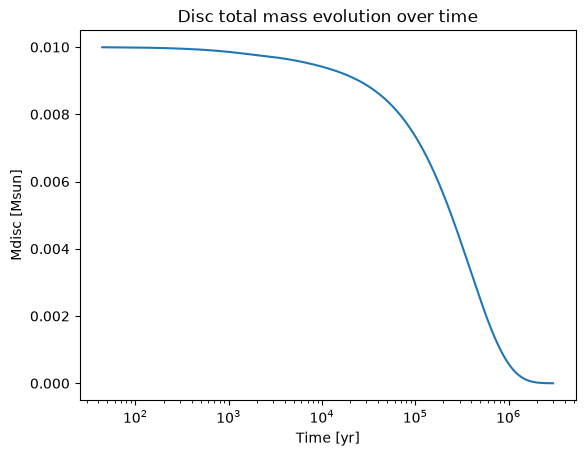

In [80]:
from DiscEvolution.constants import Msun
Mdisc_t_array = np.array(Mdisc_t)
Mdisc_t_in_Msun = Mdisc_t_array / Msun

plt.plot(t, Mdisc_t_in_Msun)
plt.title("Disc total mass evolution over time")
plt.ylabel("Mdisc [Msun]")
plt.xscale("log")
# plt.yscale("log")
plt.xlabel("Time [yr]")


Text(0.5, 0, 'Time [Myr]')

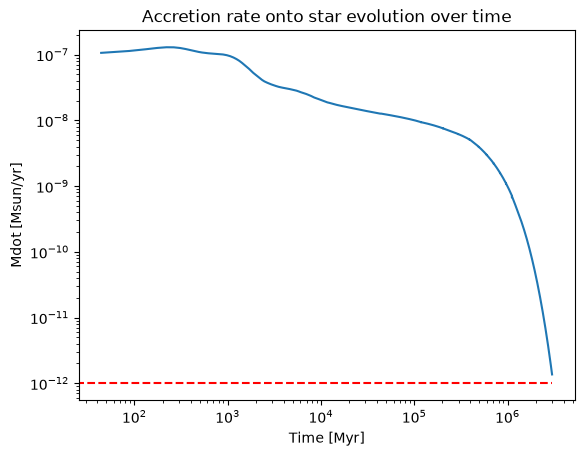

In [81]:
plt.plot(t, Mdot_t)
plt.title("Accretion rate onto star evolution over time")
plt.hlines(1e-12, 0.0, 3e6, colors="red", linestyles= "dashed")

plt.yscale("log")
plt.xscale("log")
plt.ylabel("Mdot [Msun/yr]")
plt.xlabel("Time [Myr]")


Dropping 12 trailing point(s) that don't fill a full 20-point block


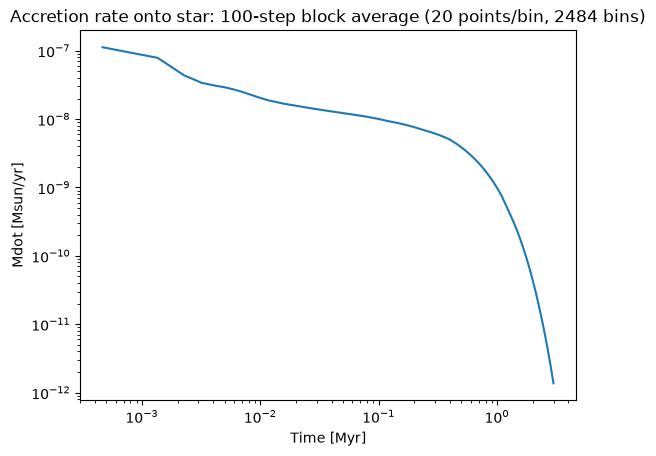

In [82]:
# Plot the average Mdot over every n=100 simulation steps
#
# disk_Mdot_star (Mdot_t) is written every 5 steps -- see run_model_Hof.py's
# _integrate(): `if (n % 5 == 0): grow_and_set(h5f["disk_Mdot_star"], ...)`.
# So n=100 simulation steps = 100/5 = 20 consecutive Mdot_t entries: each
# point on this plot IS the mean of 20 consecutive points from the log-Mdot
# plot above. This is a non-overlapping BLOCK average (decimation) -- one
# output point per 20 input points -- not a rolling/moving average (which
# `uniform_filter1d`, already imported in the first cell, would give: one
# smoothed output point per INPUT point instead).

STEPS_PER_WRITE = 5                          # cadence disk_Mdot_star is written at (run_model_Hof.py)
N_STEPS = 100                                # simulation steps to average over per output point
assert N_STEPS % STEPS_PER_WRITE == 0, "N_STEPS must be a multiple of STEPS_PER_WRITE"
block = N_STEPS // STEPS_PER_WRITE           # = 20 consecutive Mdot_t entries per output point

Mdot_t_arr = np.asarray(Mdot_t, dtype=float)   # [Msun/yr]
t_Myr_arr  = np.asarray(t_Myr, dtype=float)    # [Myr]

n_blocks = len(Mdot_t_arr) // block
n_dropped = len(Mdot_t_arr) - n_blocks * block
if n_dropped:
    print(f"Dropping {n_dropped} trailing point(s) that don't fill a full {block}-point block")

# Average of Mdot, and of the matching time values, within each block  [Msun/yr], [Myr]
Mdot_block_avg = Mdot_t_arr[:n_blocks * block].reshape(n_blocks, block).mean(axis=1)
t_block_avg    = t_Myr_arr[:n_blocks * block].reshape(n_blocks, block).mean(axis=1)

plt.plot(t_block_avg, Mdot_block_avg, '-')
plt.yscale("log")
plt.xscale("log")
plt.title(f"Accretion rate onto star: {N_STEPS}-step block average ({block} points/bin, {n_blocks} bins)")
plt.ylabel("Mdot [Msun/yr]")
plt.xlabel("Time [Myr]")
plt.show()


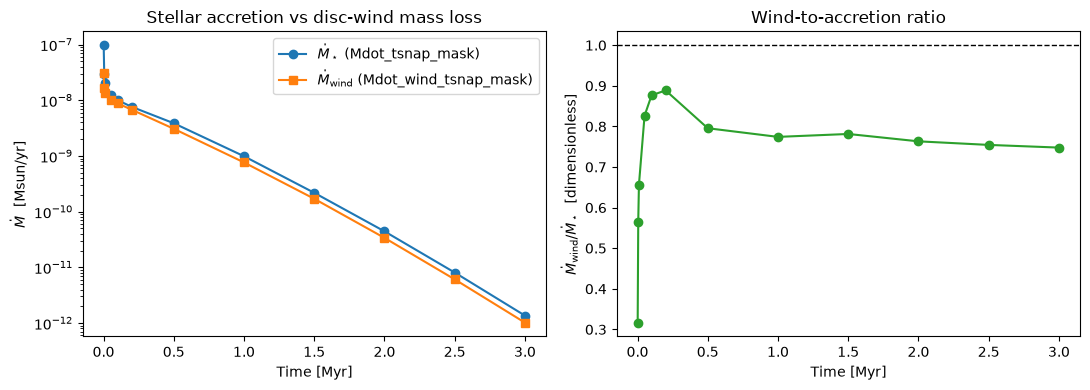

median wind/accretion ratio: 0.769  (range 0.317-0.889)


In [83]:
# Compare Mdot_tsnap_mask (accretion onto star) with Mdot_wind_tsnap_mask (disc-wind mass loss).
#
# Both come straight from integrate_wind_mass_loss_rate() in the
# "erad / t_snap_mask / Mdot_tsnap ..." cell above. That function returns the two
# rates already:
#   - PAIRED and masked to finite & strictly-positive values (the SAME mask on
#     both), so element i of each refers to the same snapshot;
#   - together with t_snap_mask, the matching snapshot times, so they can be
#     plotted against time. All three arrays therefore have equal length.
# (No physics is recomputed here -- see the diagnostic cell above for the
#  unmasked, per-snapshot recomputation.)
#
# Units:
#   Mdot_tsnap_mask       stellar accretion rate       [Msun/yr]
#   Mdot_wind_tsnap_mask   integrated disc-wind loss    [Msun/yr]
#   t_snap_mask            snapshot time                [Myr]
#   ratio                  wind / accretion             [dimensionless]
if _psi != 0:
      ratio = Mdot_wind_tsnap_mask / Mdot_tsnap_mask          # [dimensionless]

      fig, axes = plt.subplots(1, 2, figsize=(11, 4))

      # (1) both rates vs time   [Msun/yr  vs  Myr]
      ax = axes[0]
      ax.plot(t_snap_mask, Mdot_tsnap_mask,      'o-', label=r'$\dot{M}_\star$ (Mdot_tsnap_mask)')
      ax.plot(t_snap_mask, Mdot_wind_tsnap_mask, 's-', label=r'$\dot{M}_{\rm wind}$ (Mdot_wind_tsnap_mask)')
      ax.set_yscale('log')
      ax.set_xlabel("Time [Myr]")
      ax.set_ylabel(r"$\dot{M}$  [Msun/yr]")
      ax.set_title("Stellar accretion vs disc-wind mass loss")
      ax.legend()

      # (2) wind-to-accretion ratio vs time   [dimensionless  vs  Myr]
      ax = axes[1]
      ax.plot(t_snap_mask, ratio, 'o-', color='C2')
      ax.axhline(1.0, color='k', ls='--', lw=1)   # ratio = 1: wind loss balances accretion onto the star
      ax.set_xlabel("Time [Myr]")
      ax.set_ylabel(r"$\dot{M}_{\rm wind} / \dot{M}_\star$  [dimensionless]")
      ax.set_title("Wind-to-accretion ratio")

      plt.tight_layout()
      plt.show()

      print(f"median wind/accretion ratio: {np.median(ratio):.3f}  "
            f"(range {ratio.min():.3f}-{ratio.max():.3f})")


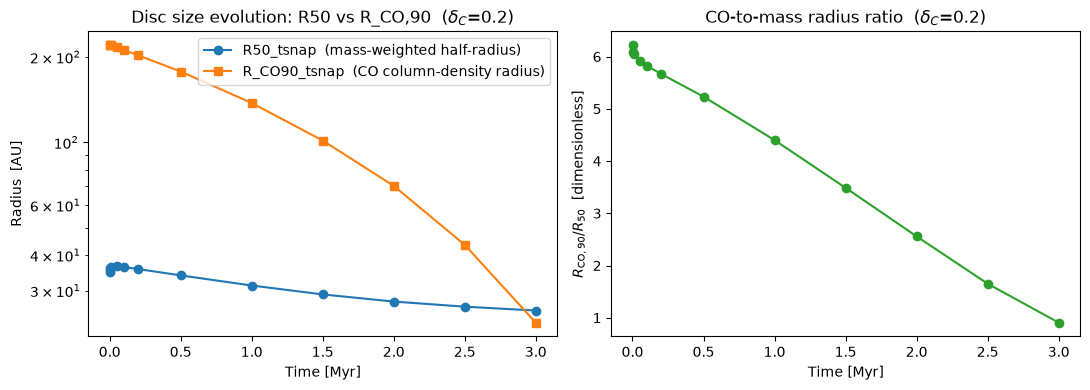

In [84]:
# Compare the evolution of R50_tsnap (mass-weighted half-radius) and
# R_CO90_tsnap (CO-column-density-threshold radius, Trapman et al. 2023 Eq. 3).

# Both are radii in AU, aligned to t_snap [Myr] 
# Profile-derived series plot against t_snap, not the dense `t` grid. 
# R_CO90_tsnap is expected to be gaps (NaN) at
# the first/last snapshot -- see the "R_CO,90" cell above for why.

ratio_CO90_50 = R_CO90_tsnap / R50_tsnap   # [dimensionless]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (1) both radii vs time   [AU  vs  Myr]
ax = axes[0]
ax.plot(t_snap, R50_tsnap,   'o-', label='R50_tsnap  (mass-weighted half-radius)')
ax.plot(t_snap, R_CO90_tsnap, 's-', label='R_CO90_tsnap  (CO column-density radius)')
ax.set_yscale('log')
ax.set_xlabel("Time [Myr]")
ax.set_ylabel("Radius  [AU]")
ax.set_title(rf"Disc size evolution: R50 vs R_CO,90  ($\delta_C$={delta_C})")
ax.legend()

# (2) R_CO90 / R50 ratio vs time   [dimensionless  vs  Myr]
ax = axes[1]
ax.plot(t_snap, ratio_CO90_50, 'o-', color='C2')
ax.set_xlabel("Time [Myr]")
ax.set_ylabel(r"$R_{\rm CO,90} / R_{50}$  [dimensionless]")
ax.set_title(rf"CO-to-mass radius ratio  ($\delta_C$={delta_C})")

plt.tight_layout()
plt.show()

saved /home/imontesd/output/DiscEvolution/figures/hof_discwind_sweep2.02_boundary_Mdot_inn_psi100_erad0.9_Mdot1.0e-07_M1.0e-02_Rd5.0e+01_SigmaG_RCO90_movie.gif (13 frames)


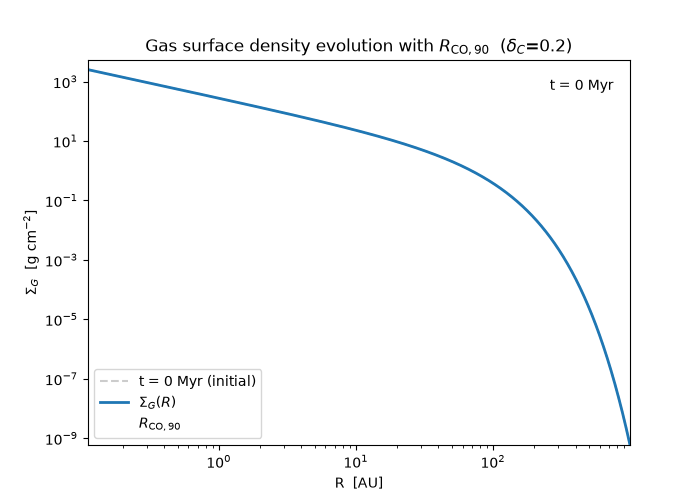

saved /home/imontesd/output/DiscEvolution/figures/hof_discwind_sweep2.02_boundary_Mdot_inn_psi100_erad0.9_Mdot1.0e-07_M1.0e-02_Rd5.0e+01_CMF_RCO90_movie.gif (13 frames)


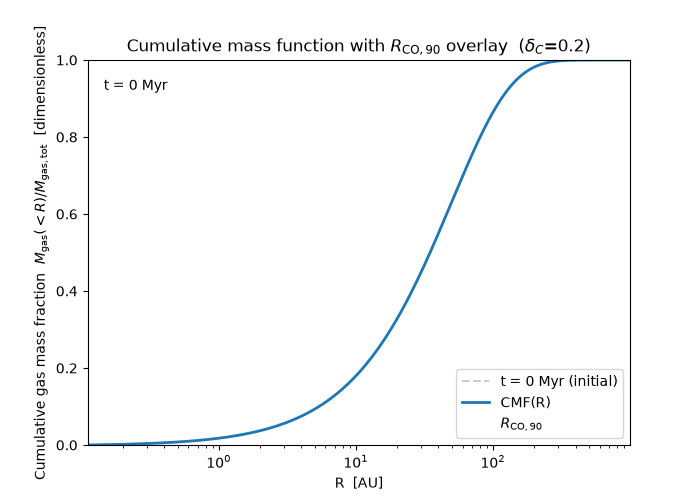

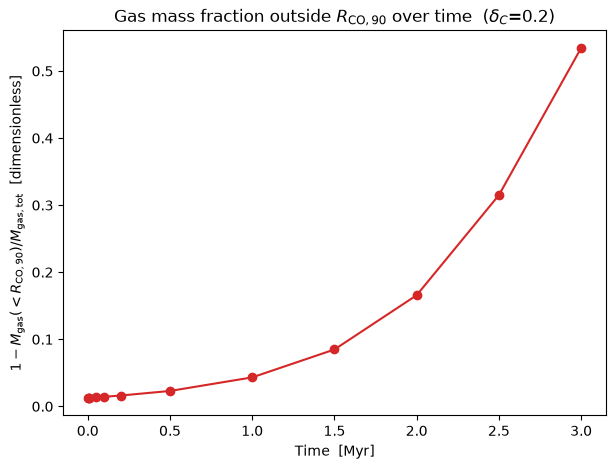

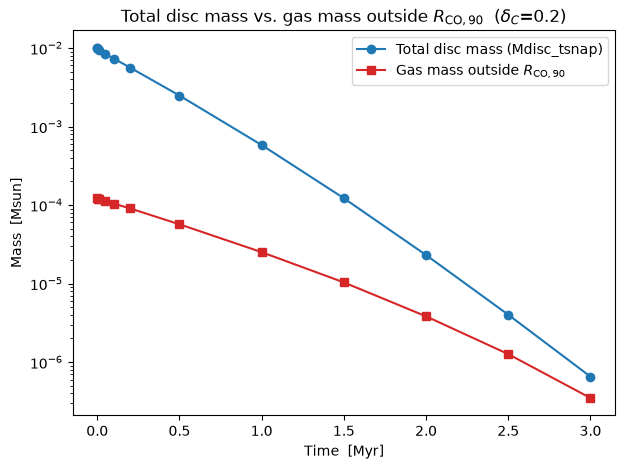

In [91]:
# Combined R_CO90 diagnostics cell (previously two separate cells):
#
#   (1) Movie of Sigma_G(R) profile evolution with a dashed line overlay that
#       shows the location of R_CO90 at every time it is saved (to disk, if
#       `save` is True -- see below).
#   (2) Movie of the cumulative mass function (x = radius, y = fraction of
#       total gas mass, range 0 to 1), with a dashed line overlay showing the
#       location of R_CO90, and a horizontal line projecting the intersection
#       of R_CO90 with the cumulative mass distribution function onto the
#       y-axis, at every time it is saved (to disk, if `save` is True).
#   (3) Stationary plot of y = 1 - intercept (i.e. how much gas mass is
#       outside R_CO90) at every time step.
#   (4) NEW: stationary overlay of total disc mass and (absolute) mass
#       outside R_CO90, both vs time.
#
# (1) and (2) use Sigma_G(R) (gas only), not Sigma_total_tsnap -- R_CO90_tsnap
# (the "R_CO_90" cell above) is derived from the gas column density N_gas(R) =
# Sigma_G / (mu*m_H), so keeping the overlay on gas-only quantities means the
# dashed line and the curve/plot it marks describe the same physical quantity.
#
# Both movies use the same GIF-via-PillowWriter convention as the
# Sigma_total(R,t) movie cells further below (Pillow only, no ffmpeg needed),
# saved into FIGDIR and shown inline. FRAME_STEP/FPS/MAKE_MP4 are defined once
# here and shared by both movies.
#
# Saving to disk is optional (toggled with `save` below) -- when save=False,
# NOTHING is written to FIGDIR; the animation is still rendered and shown
# inline in the notebook, just via to_jshtml() (an embedded HTML5 player)
# instead of a saved-then-reloaded GIF file.
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from IPython.display import Image, HTML, display

FRAME_STEP = 1        # use every FRAME_STEP-th snapshot [dimensionless]; raise to shorten the movies
FPS = 5                # playback speed [frames/s]
MAKE_MP4 = False       # also write an .mp4 (requires ffmpeg) -- only takes effect if save=True
save = True            # write the movie GIF (and optionally .mp4) to FIGDIR; if False, no files are written

R_au = np.asarray(data["R"], dtype=float)                   # [AU]
Sigma_G_tsnap = np.asarray(data["Sigma_G"], dtype=float)    # [g/cm^2], one row per t_snap
n_snap_cmf = len(t_snap)
frames_all = np.arange(0, n_snap_cmf, FRAME_STEP)            # snapshot indices used as frames, shared by both movies


# ---------------------------------------------------------------------------
# (1) Movie: Sigma_G(R,t) with R_CO90 overlay
# ---------------------------------------------------------------------------
# Fixed axes for every frame (otherwise the axes jump around and the movie is
# unreadable). Log axes need strictly positive limits, so take min over Sigma_G > 0.
Sigma_G_pos = Sigma_G_tsnap[Sigma_G_tsnap > 0]              # [g/cm^2]
y_min, y_max = Sigma_G_pos.min(), Sigma_G_pos.max()         # [g/cm^2]

fig_rco, ax_rco = plt.subplots(figsize=(7, 5))
ax_rco.plot(R_au, Sigma_G_tsnap[0], color="gray", alpha=0.4, ls="--",
            label=f"t = {t_snap[0]:.3g} Myr (initial)")            # static reference profile
line_rco, = ax_rco.plot([], [], color="C0", lw=2, label=r"$\Sigma_G(R)$")   # updated every frame
vline_rco = ax_rco.axvline(R_au[0], color="C3", ls="--", lw=1.5, alpha=0.0,
                            label=r"$R_{\rm CO,90}$")                        # updated every frame
time_txt_rco = ax_rco.text(0.97, 0.95, "", transform=ax_rco.transAxes, ha="right", va="top")
ax_rco.set_xscale("log")
ax_rco.set_yscale("log")
ax_rco.set_xlim(R_au.min(), R_au.max())                     # [AU]
ax_rco.set_ylim(y_min, y_max * 2)                           # [g/cm^2]
ax_rco.set_xlabel("R  [AU]")
ax_rco.set_ylabel(r"$\Sigma_G$  [g cm$^{-2}$]")
ax_rco.set_title(rf"Gas surface density evolution with $R_{{\rm CO,90}}$  ($\delta_C$={delta_C})")
ax_rco.legend(loc="lower left")

def _update_rco(i):
    """Draw snapshot i (index into t_snap / Sigma_G_tsnap / R_CO90_tsnap)."""
    line_rco.set_data(R_au, Sigma_G_tsnap[i])
    time_txt_rco.set_text(f"t = {t_snap[i]:.3g} Myr")
    r_co90 = R_CO90_tsnap[i]                                 # [AU], may be NaN
    if np.isfinite(r_co90):
        vline_rco.set_xdata([r_co90, r_co90])
        vline_rco.set_alpha(1.0)
    else:
        vline_rco.set_alpha(0.0)                             # hide the line for NaN snapshots
    return line_rco, vline_rco, time_txt_rco

anim_rco = FuncAnimation(fig_rco, _update_rco, frames=frames_all, blit=False)

if save:
    # Output name: same as the h5 file, with a SigmaG/RCO90-movie suffix
    movie_base_rco = os.path.join(FIGDIR, os.path.splitext(os.path.basename(filename))[0] + "_SigmaG_RCO90_movie")
    os.makedirs(FIGDIR, exist_ok=True)
    anim_rco.save(movie_base_rco + ".gif", writer=PillowWriter(fps=FPS))
    print("saved", movie_base_rco + ".gif", f"({len(frames_all)} frames)")

    if MAKE_MP4:
        try:
            anim_rco.save(movie_base_rco + ".mp4", writer=FFMpegWriter(fps=FPS))
            print("saved", movie_base_rco + ".mp4")
        except Exception as e:
            print(f"mp4 skipped ({type(e).__name__}: {e})")

    plt.close(fig_rco)                        # don't also show the static last frame
    display(Image(filename=movie_base_rco + ".gif"))
else:
    plt.close(fig_rco)                        # don't also show the static last frame
    display(HTML(anim_rco.to_jshtml()))       # rendered inline, nothing written to disk


# ---------------------------------------------------------------------------
# (2) Movie: cumulative mass function CMF(R,t) with R_CO90 overlay
# ---------------------------------------------------------------------------
# CMF(R) = cumulative gas mass out to R, divided by that snapshot's total gas
# mass -- the same cumulative-mass integral R50() (the "R50_tsnap" cell above)
# uses, just returned as the full normalized array (0 -> 1) instead of
# interpolated to a single radius. The AU/cm^2 units of R*Sigma_G don't need
# converting to grams here since we only ever use the ratio M_cum(R)/M_cum_total
# -- the unit factor cancels.

def cumulative_mass_fraction(R, Sigma_G_row):
    """Cumulative gas-mass fraction M_gas(<R) / M_gas_total(R), dimensionless, same length as R."""
    dM = 2*np.pi*R*Sigma_G_row                                                   # unnormalized mass element
    M_cum = np.concatenate([[0], np.cumsum(0.5*(dM[1:]+dM[:-1])*np.diff(R))])    # unnormalized cumulative mass
    return M_cum / M_cum[-1]                                                     # [dimensionless], 0 -> 1

CMF_tsnap = np.array([cumulative_mass_fraction(R_au, row) for row in Sigma_G_tsnap])   # [dimensionless], (n_snap, nR)

# Cumulative mass fraction AT R_CO90 for each snapshot -- the y-value where the
# dashed R_CO90 vertical line intersects that snapshot's own CMF(R) curve. NaN
# where R_CO90_tsnap[i] itself is NaN (see the "R_CO_90" cell for why).
intercept_frac_tsnap = np.array([
    np.interp(r_co90, R_au, cmf_row) if np.isfinite(r_co90) else np.nan
    for r_co90, cmf_row in zip(R_CO90_tsnap, CMF_tsnap)
])                                                             # [dimensionless]
outside_frac_tsnap = 1 - intercept_frac_tsnap                  # [dimensionless]: gas mass fraction OUTSIDE R_CO90

fig_cmf, ax_cmf = plt.subplots(figsize=(7, 5))
ax_cmf.plot(R_au, CMF_tsnap[0], color="gray", alpha=0.4, ls="--",
            label=f"t = {t_snap[0]:.3g} Myr (initial)")             # static reference profile
line_cmf, = ax_cmf.plot([], [], color="C0", lw=2, label="CMF(R)")    # updated every frame
vline_cmf = ax_cmf.axvline(R_au[0], color="C3", ls="--", lw=1.5, alpha=0.0,
                            label=r"$R_{\rm CO,90}$")                 # updated every frame
hline_cmf, = ax_cmf.plot([], [], color="C3", ls=":", lw=1)            # R_CO90 projection onto y-axis, updated every frame
time_txt_cmf = ax_cmf.text(0.03, 0.95, "", transform=ax_cmf.transAxes, ha="left", va="top")
ax_cmf.set_xscale("log")
ax_cmf.set_xlim(R_au.min(), R_au.max())                        # [AU]
ax_cmf.set_ylim(0, 1)                                           # [dimensionless]
ax_cmf.set_xlabel("R  [AU]")
ax_cmf.set_ylabel(r"Cumulative gas mass fraction  $M_{\rm gas}(<R) / M_{\rm gas,tot}$  [dimensionless]")
ax_cmf.set_title(rf"Cumulative mass function with $R_{{\rm CO,90}}$ overlay  ($\delta_C$={delta_C})")
ax_cmf.legend(loc="lower right")

def _update_cmf(i):
    """Draw snapshot i (index into t_snap / CMF_tsnap / R_CO90_tsnap / intercept_frac_tsnap)."""
    line_cmf.set_data(R_au, CMF_tsnap[i])
    time_txt_cmf.set_text(f"t = {t_snap[i]:.3g} Myr")
    r_co90 = R_CO90_tsnap[i]                                    # [AU], may be NaN
    frac = intercept_frac_tsnap[i]                              # [dimensionless], may be NaN
    if np.isfinite(r_co90):
        vline_cmf.set_xdata([r_co90, r_co90])
        vline_cmf.set_alpha(1.0)
        hline_cmf.set_data([R_au.min(), r_co90], [frac, frac])
        hline_cmf.set_alpha(1.0)
    else:
        vline_cmf.set_alpha(0.0)                                # hide both overlay lines for NaN snapshots
        hline_cmf.set_alpha(0.0)
    return line_cmf, vline_cmf, hline_cmf, time_txt_cmf

anim_cmf = FuncAnimation(fig_cmf, _update_cmf, frames=frames_all, blit=False)

if save:
    # Output name: same as the h5 file, with a CMF/RCO90-movie suffix
    movie_base_cmf = os.path.join(FIGDIR, os.path.splitext(os.path.basename(filename))[0] + "_CMF_RCO90_movie")
    os.makedirs(FIGDIR, exist_ok=True)
    anim_cmf.save(movie_base_cmf + ".gif", writer=PillowWriter(fps=FPS))
    print("saved", movie_base_cmf + ".gif", f"({len(frames_all)} frames)")

    if MAKE_MP4:
        try:
            anim_cmf.save(movie_base_cmf + ".mp4", writer=FFMpegWriter(fps=FPS))
            print("saved", movie_base_cmf + ".mp4")
        except Exception as e:
            print(f"mp4 skipped ({type(e).__name__}: {e})")

    plt.close(fig_cmf)                        # don't also show the static last frame
    display(Image(filename=movie_base_cmf + ".gif"))
else:
    plt.close(fig_cmf)                        # don't also show the static last frame
    display(HTML(anim_cmf.to_jshtml()))       # rendered inline, nothing written to disk


# ---------------------------------------------------------------------------
# (3) Stationary plot: gas mass fraction OUTSIDE R_CO90 vs time
# ---------------------------------------------------------------------------
fig_out, ax_out = plt.subplots(figsize=(7, 5))
ax_out.plot(t_snap, outside_frac_tsnap, 'o-', color='C3')
ax_out.set_xlabel("Time  [Myr]")
ax_out.set_ylabel(r"$1 - M_{\rm gas}(<R_{\rm CO,90}) / M_{\rm gas,tot}$  [dimensionless]")
ax_out.set_title(rf"Gas mass fraction outside $R_{{\rm CO,90}}$ over time  ($\delta_C$={delta_C})")
plt.show()


# ---------------------------------------------------------------------------
# (4) NEW -- Stationary plot: total disc mass vs (absolute) mass outside R_CO90
# ---------------------------------------------------------------------------
# Total disc mass = Mdisc_tsnap [Msun] (gas+dust+pebbles[+planetesimals], the
# "tau" cell above -- same quantity as the "Balogh et al. 2026" Sigma_total
# figure integrates).
#
# Mass outside R_CO90 = outside_frac_tsnap (dimensionless, computed in part (2)
# above) x Mgas_tsnap [Msun] (the "Mgas_tsnap" cell above) -- outside_frac_tsnap
# is a fraction of the GAS mass (it comes from the Sigma_G-based CMF), so it
# must be converted to an absolute mass using the gas mass total, not the
# gas+dust+pebbles total disc mass.
mass_outside_RCO90_tsnap = outside_frac_tsnap * np.asarray(Mgas_tsnap, dtype=float)   # [Msun]

fig_mass, ax_mass = plt.subplots(figsize=(7, 5))
ax_mass.plot(t_snap, Mdisc_tsnap, 'o-', color='C0', label='Total disc mass (Mdisc_tsnap)')
ax_mass.plot(t_snap, mass_outside_RCO90_tsnap, 's-', color='C3', label=r'Gas mass outside $R_{\rm CO,90}$')
ax_mass.set_yscale('log')
ax_mass.set_xlabel("Time  [Myr]")
ax_mass.set_ylabel("Mass  [Msun]")
ax_mass.set_title(rf"Total disc mass vs. gas mass outside $R_{{\rm CO,90}}$  ($\delta_C$={delta_C})")
ax_mass.legend()
plt.show()

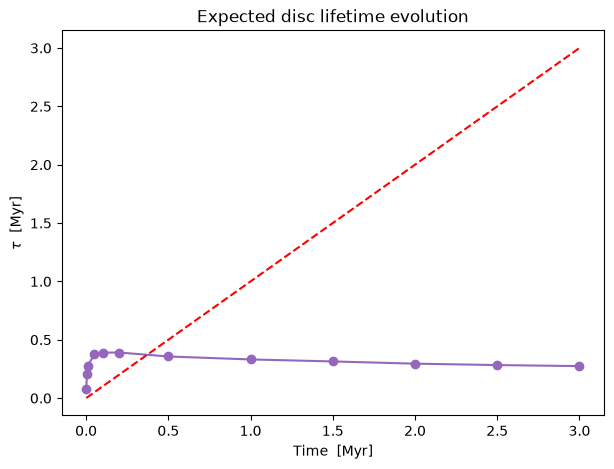

In [86]:
# Plot that shows time evolution of expected disc lifetime tau 

# tau_Myr (from the "tau" cell above) is aligned to t_snap_mask [Myr] -- the subset
# of snapshots where both Mdot_tsnap_mask and Mdot_wind_tsnap_mask are defined (see
# that cell's comments for why the first/last snapshot are dropped). tau itself is
# the instantaneous depletion timescale disc mass / (accretion + wind loss) [Myr];
# a rising tau over time means the total mass-loss rate is falling faster than the
# disc mass itself -- i.e. the disc is depleting more slowly, in relative terms, as
# it evolves.

fig, ax = plt.subplots(figsize=(7, 5))
if _psi != 0:
    ax.plot(t_snap_mask, tau_Myr, 'o-', color='C4')
    ax.plot(t_snap_mask, t_snap_mask, '--', color = "red")
else:
    ax.plot(t_snap, tau_Myr, 'o-', color='C4')
    ax.plot(t_snap, t_snap, '--', color = "red")

ax.set_xlabel("Time  [Myr]")
ax.set_ylabel(r"$\tau$  [Myr]")
ax.set_title("Expected disc lifetime evolution")
plt.show()


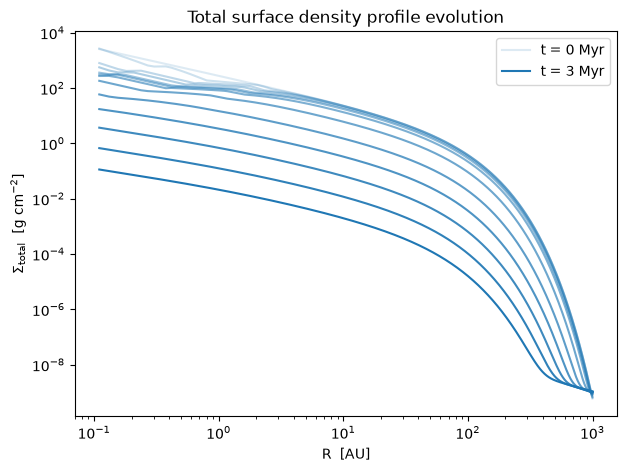

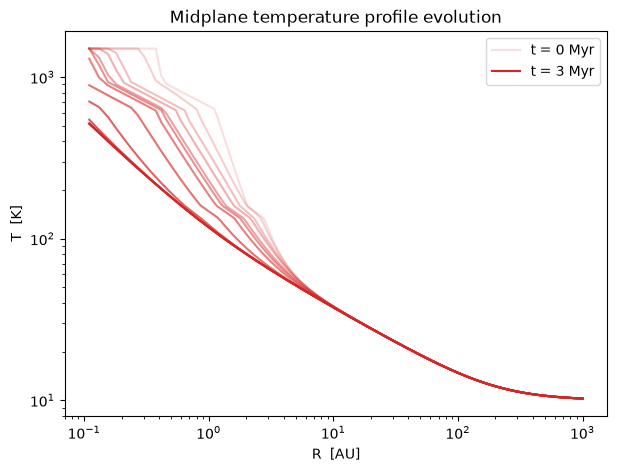

In [87]:
# A series of more in-depth plots analogous to Figure 4,5 in Balogh et al. 2026
# where we study several observables as a function of radius,
# including Sigma, T. Add series for every time snapshot, with color same color but 
# opacity increasing over time.
# Each observable has a separate figure

# Shared time-opacity convention for all three figures below: every line in a given
# figure uses the SAME base color (one color per observable/population), and only
# the alpha (opacity) changes with snapshot -- faint/light = early time, fully
# opaque = the most recent snapshot.

R_au = np.asarray(data["R"], dtype=float)      # [AU]
n_snap = len(t_snap)
alphas = np.linspace(0.15, 1.0, n_snap)        # opacity ramp: faint (early) -> opaque (late)

def _time_label(i, prefix=""):
    """Legend label for the first/last snapshot only; None (no legend entry) otherwise."""
    if i == 0:
        return f"{prefix}t = {t_snap[i]:.3g} Myr"
    if i == n_snap - 1:
        return f"{prefix}t = {t_snap[i]:.3g} Myr"
    return None


# ---------------------------------------------------------------------------
# Figure 1: Sigma(R) -- total (gas+dust) surface density, one line per snapshot
# ---------------------------------------------------------------------------
# Uses Sigma_total_tsnap from the "tau" cell above (full mass, not gas-only
# Sigma_G) -- units [g/cm^2]. Swap in data["Sigma_G"] instead if gas-only is
# wanted.
fig1, ax1 = plt.subplots(figsize=(7, 5))
color_sigma = "C0"
for i in range(n_snap):
    ax1.plot(R_au, Sigma_total_tsnap[i], color=color_sigma, alpha=alphas[i],
              label=_time_label(i))
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel("R  [AU]")
ax1.set_ylabel(r"$\Sigma_{\rm total}$  [g cm$^{-2}$]")
ax1.set_title("Total surface density profile evolution")
ax1.legend()
plt.show()


# ---------------------------------------------------------------------------
# Figure 2: T(R) -- midplane temperature, one line per snapshot
# ---------------------------------------------------------------------------
Temp_tsnap = np.asarray(data["T"], dtype=float)   # [K], one row per t_snap
fig2, ax2 = plt.subplots(figsize=(7, 5))
color_T = "C3"
for i in range(n_snap):
    ax2.plot(R_au, Temp_tsnap[i], color=color_T, alpha=alphas[i],
              label=_time_label(i))
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.set_xlabel("R  [AU]")
ax2.set_ylabel("T  [K]")
ax2.set_title("Midplane temperature profile evolution")
ax2.legend()
plt.show()


In [88]:
# Add plot for dense array of Sigma_G
#
# Sigma_G_dense / Sigma_G_dense_t (data loaded by load_data() above) only exist
# in output from run_model_Hof_dense.py (filename contains "_dense_") -- they
# give Sigma_G(R) at FULL time resolution (a candidate write every 5 steps,
# same cadence as disk_Mdot_star/disk_Mass/Tc/Sigc) within the
# [DENSE_T_MIN_MYR, DENSE_T_MAX_MYR] window that run was configured with, e.g.
# thousands of rows -- vs. the 13-point time_snap grid every other profile
# (Sigma_G, T, ...) is stuck with.
#
# That many rows is too many to overlay as individual lines (unlike the
# sparse per-snapshot Sigma(R) figure above, which uses one line per t_snap
# with an opacity ramp) -- so this is rendered as a 2D heatmap instead:
#   x = R              [AU]
#   y = Sigma_G_dense_t [Myr]   (its OWN timestamps -- do not use t_snap here)
#   color = Sigma_G     [g/cm^2]  (log-scaled: spans several orders of magnitude)
#
# ZOOMED to a small radial window just outside the grid's inner edge
# (R > R_ZOOM_MIN, R_ZOOM_MIN just above 0.1 AU = grid rmin -- see
# DiscConfig_Hof_baseline.json / DiscConfig_Hof_sweep.json's grid.rmin) so any
# fluctuations near the inner boundary (inner-boundary-condition artifacts,
# grid-resolution effects, etc.) are easier to see than in the full 0.1-1000
# AU view above. Adjust R_ZOOM_MIN / R_ZOOM_MAX below to widen/narrow/shift
# the window; the rest of the plot logic is unchanged from the full-range
# version.

if "Sigma_G_dense" not in data:
    print("This file has no Sigma_G_dense dataset -- point `filename` (a few "
          "cells above) at a run_model_Hof_dense.py output (filename contains "
          "'_dense_') to use this cell.")
else:
    R_ZOOM_MIN = 0.1   # [AU] -- just above the grid's inner edge (rmin)
    R_ZOOM_MAX = 1.0   # [AU] -- upper edge of the zoomed-in window

    R_au_full          = np.asarray(data["R"], dtype=float)                      # [AU]
    t_dense_Myr        = np.asarray(data["Sigma_G_dense_t"], dtype=float) / 1e6  # [years] -> [Myr]
    Sigma_G_dense_full  = np.asarray(data["Sigma_G_dense"], dtype=float)          # [g/cm^2], (n_dense, nR)

    in_zoom = (R_au_full > R_ZOOM_MIN) & (R_au_full <= R_ZOOM_MAX)   # boolean mask over the radial grid
    R_au          = R_au_full[in_zoom]                # [AU], zoomed-in radial grid
    Sigma_G_dense = Sigma_G_dense_full[:, in_zoom]     # [g/cm^2], (n_dense, n_zoom_cells)

    positive = Sigma_G_dense[Sigma_G_dense > 0]   # LogNorm needs strictly-positive bounds
    vmin, vmax = positive.min(), positive.max()

    fig, ax = plt.subplots(figsize=(8, 5))
    pcm = ax.pcolormesh(R_au, t_dense_Myr, Sigma_G_dense,
                         norm=LogNorm(vmin=vmin, vmax=vmax),
                         shading="auto", cmap="viridis")
    ax.set_xscale("log")
    ax.set_xlabel("R  [AU]")
    ax.set_ylabel("Time  [Myr]")
    ax.set_title(f"Dense $\\Sigma_G(R,t)$, inner-disc zoom "
                 f"({R_ZOOM_MIN:.3g}-{R_ZOOM_MAX:.3g} AU)  --  "
                 f"{t_dense_Myr[0]:.3g}-{t_dense_Myr[-1]:.3g} Myr, "
                 f"{Sigma_G_dense.shape[0]} timesteps")
    cbar = fig.colorbar(pcm, ax=ax)
    cbar.set_label(r"$\Sigma_G$  [g cm$^{-2}$]")
    plt.show()


This file has no Sigma_G_dense dataset -- point `filename` (a few cells above) at a run_model_Hof_dense.py output (filename contains '_dense_') to use this cell.


saved /home/imontesd/output/DiscEvolution/figures/hof_discwind_sweep2.02_boundary_Mdot_inn_psi100_erad0.9_Mdot1.0e-07_M1.0e-02_Rd5.0e+01_Sigma_movie.gif (13 frames)


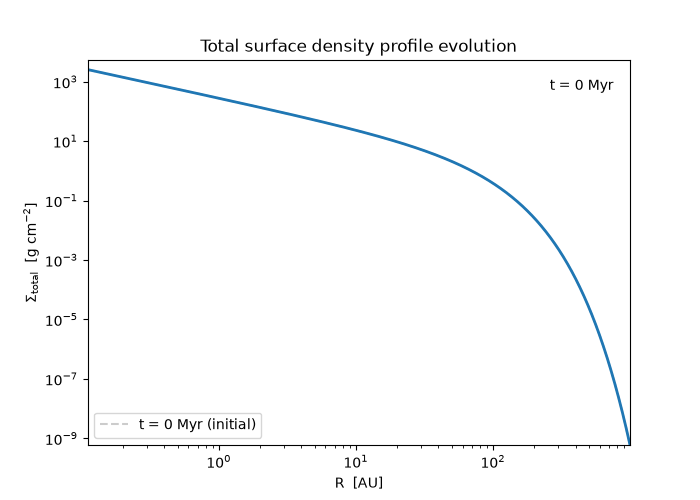

In [89]:
# Movie of the total surface density profile evolution, Sigma_total(R, t)
#
# One frame per t_snap snapshot, using Sigma_total_tsnap [g/cm^2] and R_au [AU]
# from the "tau" cell above (gas + dust + pebbles [+ planetesimals]) -- the same
# quantity as Figure 1 of the "Balogh et al. 2026" cell, but animated instead of
# overlaid. Frame i is the profile at t_snap[i] [Myr]; the t = t_snap[0] profile
# is kept as a faint grey reference line so the eye can see how far the disc
# has moved from its initial state.
#
# Output: a GIF written with matplotlib's PillowWriter (Pillow only, no ffmpeg
# needed), saved into FIGDIR. It is also shown inline below the cell.
# Set MAKE_MP4 = True to additionally write an .mp4 -- this needs ffmpeg on PATH
# and is skipped with a message if it is not found.
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from IPython.display import Image, display

FRAME_STEP = 1        # use every FRAME_STEP-th snapshot [dimensionless]; raise to shorten the movie
FPS = 5               # playback speed [frames/s]
MAKE_MP4 = False      # also write an .mp4 (requires ffmpeg)

R_au = np.asarray(data["R"], dtype=float)                 # [AU]
frames = np.arange(0, len(t_snap), FRAME_STEP)            # snapshot indices used as frames

# Fixed axes for every frame (otherwise the axes jump around and the movie is
# unreadable). Log axes need strictly positive limits, so take min over Sigma > 0.
Sigma_pos = Sigma_total_tsnap[Sigma_total_tsnap > 0]      # [g/cm^2]
y_min, y_max = Sigma_pos.min(), Sigma_pos.max()           # [g/cm^2]

fig_mv, ax_mv = plt.subplots(figsize=(7, 5))
ax_mv.plot(R_au, Sigma_total_tsnap[0], color="gray", alpha=0.4, ls="--",
           label=f"t = {t_snap[0]:.3g} Myr (initial)")     # static reference profile
line_mv, = ax_mv.plot([], [], color="C0", lw=2)            # line updated every frame
time_txt = ax_mv.text(0.97, 0.95, "", transform=ax_mv.transAxes, ha="right", va="top")
ax_mv.set_xscale("log")
ax_mv.set_yscale("log")
ax_mv.set_xlim(R_au.min(), R_au.max())                     # [AU]
ax_mv.set_ylim(y_min, y_max * 2)                           # [g/cm^2]
ax_mv.set_xlabel("R  [AU]")
ax_mv.set_ylabel(r"$\Sigma_{\rm total}$  [g cm$^{-2}$]")
ax_mv.set_title("Total surface density profile evolution")
ax_mv.legend(loc="lower left")

def _update(i):
    """Draw snapshot i (index into t_snap / Sigma_total_tsnap)."""
    line_mv.set_data(R_au, Sigma_total_tsnap[i])
    time_txt.set_text(f"t = {t_snap[i]:.3g} Myr")
    return line_mv, time_txt

anim = FuncAnimation(fig_mv, _update, frames=frames, blit=False)

# Output name: same as the h5 file, with a Sigma-movie suffix
movie_base = os.path.join(FIGDIR, os.path.splitext(os.path.basename(filename))[0] + "_Sigma_movie")
os.makedirs(FIGDIR, exist_ok=True)
anim.save(movie_base + ".gif", writer=PillowWriter(fps=FPS))
print("saved", movie_base + ".gif", f"({len(frames)} frames)")

if MAKE_MP4:
    try:
        anim.save(movie_base + ".mp4", writer=FFMpegWriter(fps=FPS))
        print("saved", movie_base + ".mp4")
    except Exception as e:
        print(f"mp4 skipped ({type(e).__name__}: {e})")

plt.close(fig_mv)                       # don't also show the static last frame
display(Image(filename=movie_base + ".gif"))


<>:41: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:41: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
/tmp/ipykernel_170707/1683987565.py:41: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  ax_mv100.set_title(f"Total surface density profile evolution (R $\leq$ {R_CUTOFF_AU:.0f} AU)")


saved /home/imontesd/output/DiscEvolution/figures/hof_discwind_sweep2.02_boundary_Mdot_inn_psi100_erad0.9_Mdot1.0e-07_M1.0e-02_Rd5.0e+01_Sigma_movie_100AU.gif (13 frames, R <= 100 AU)


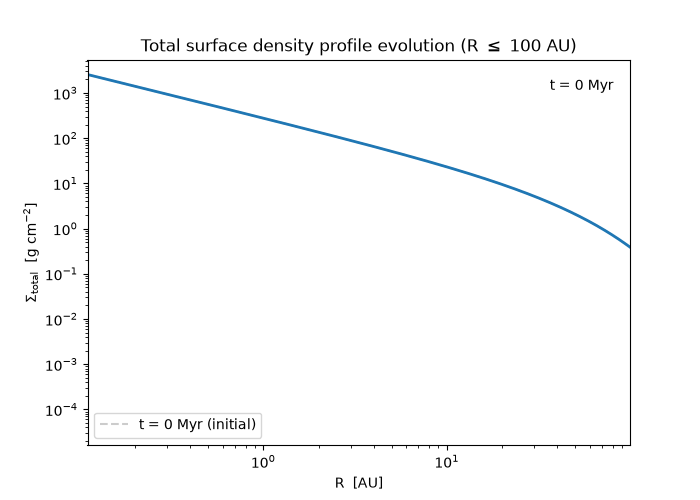

In [90]:
# Movie of the total surface density profile evolution, Sigma_total(R, t),
# ZOOMED to R <= 100 AU
#
# Same as the Sigma(R,t) movie cell above, but with the x-axis (radial) range
# restricted to R_CUTOFF_AU = 100 AU so the inner/mid-disc evolution is easier
# to see without the outer disc (R up to R_au.max(), typically ~1000 AU)
# compressing everything on the log-x axis. Uses the same
# Sigma_total_tsnap [g/cm^2] and R_au [AU] arrays defined in the "tau" cell /
# the full-range movie cell above -- only the radial mask and output
# filename differ.
from matplotlib.animation import FuncAnimation, PillowWriter, FFMpegWriter
from IPython.display import Image, display

R_CUTOFF_AU = 100.0   # [AU] -- only plot grid cells with R <= this value

# Boolean mask over the radial grid, applied to both R_au and every
# Sigma_total_tsnap[i] profile so x- and y-data stay aligned.
r_mask_100au = R_au <= R_CUTOFF_AU        # [AU] <= [AU] -> dimensionless bool mask
R_au_100 = R_au[r_mask_100au]             # [AU], radial grid restricted to <= 100 AU
Sigma_total_tsnap_100 = Sigma_total_tsnap[:, r_mask_100au]   # [g/cm^2], same restriction applied to every snapshot row

frames_100 = np.arange(0, len(t_snap), FRAME_STEP)   # reuse FRAME_STEP/FPS/MAKE_MP4 from the cell above

# Fixed y-axis limits computed ONLY from the R <= 100 AU data (not the full
# R_au range), so the zoomed-in movie uses its own y-scale rather than
# inheriting the full-disc one.
Sigma_pos_100 = Sigma_total_tsnap_100[Sigma_total_tsnap_100 > 0]   # [g/cm^2], strictly positive for log-y
y_min_100, y_max_100 = Sigma_pos_100.min(), Sigma_pos_100.max()    # [g/cm^2]

fig_mv100, ax_mv100 = plt.subplots(figsize=(7, 5))
ax_mv100.plot(R_au_100, Sigma_total_tsnap_100[0], color="gray", alpha=0.4, ls="--",
              label=f"t = {t_snap[0]:.3g} Myr (initial)")   # static reference profile
line_mv100, = ax_mv100.plot([], [], color="C0", lw=2)        # line updated every frame
time_txt_100 = ax_mv100.text(0.97, 0.95, "", transform=ax_mv100.transAxes, ha="right", va="top")
ax_mv100.set_xscale("log")
ax_mv100.set_yscale("log")
ax_mv100.set_xlim(R_au_100.min(), R_au_100.max())            # [AU], capped at R_CUTOFF_AU
ax_mv100.set_ylim(y_min_100, y_max_100 * 2)                  # [g/cm^2]
ax_mv100.set_xlabel("R  [AU]")
ax_mv100.set_ylabel(r"$\Sigma_{\rm total}$  [g cm$^{-2}$]")
ax_mv100.set_title(f"Total surface density profile evolution (R $\leq$ {R_CUTOFF_AU:.0f} AU)")
ax_mv100.legend(loc="lower left")

def _update_100(i):
    """Draw snapshot i (index into t_snap / Sigma_total_tsnap_100), R <= 100 AU only."""
    line_mv100.set_data(R_au_100, Sigma_total_tsnap_100[i])
    time_txt_100.set_text(f"t = {t_snap[i]:.3g} Myr")
    return line_mv100, time_txt_100

anim_100 = FuncAnimation(fig_mv100, _update_100, frames=frames_100, blit=False)

# Output name: same convention as the full-range movie, with a distinct
# "_100AU" suffix so it doesn't overwrite the full-range GIF.
movie_base_100 = os.path.join(FIGDIR, os.path.splitext(os.path.basename(filename))[0] + "_Sigma_movie_100AU")
os.makedirs(FIGDIR, exist_ok=True)
anim_100.save(movie_base_100 + ".gif", writer=PillowWriter(fps=FPS))
print("saved", movie_base_100 + ".gif", f"({len(frames_100)} frames, R <= {R_CUTOFF_AU:.0f} AU)")

if MAKE_MP4:
    try:
        anim_100.save(movie_base_100 + ".mp4", writer=FFMpegWriter(fps=FPS))
        print("saved", movie_base_100 + ".mp4")
    except Exception as e:
        print(f"mp4 skipped ({type(e).__name__}: {e})")

plt.close(fig_mv100)                    # don't also show the static last frame
display(Image(filename=movie_base_100 + ".gif"))
